In [1]:
import copernicusmarine

In [2]:
%%time
ds = copernicusmarine.open_dataset(dataset_id='cmems_mod_med_phy-temp_my_4.2km_P1D-m')

INFO - 2026-04-23T09:01:22Z - Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register


Copernicus Marine username:

  lfortunato


Copernicus Marine password:

  ········


INFO - 2026-04-23T09:01:40Z - Selected dataset version: "202511"
INFO - 2026-04-23T09:01:40Z - Selected dataset part: "default"


CPU times: user 3.53 s, sys: 798 ms, total: 4.33 s
Wall time: 24.2 s


In [3]:
ds


<xarray.Dataset> Size: 3TB
Dimensions:    (depth: 141, latitude: 380, longitude: 1016, time: 14335)
Coordinates:
  * depth      (depth) float32 564B 1.018 3.166 5.465 ... 5.646e+03 5.754e+03
  * latitude   (latitude) float32 2kB 30.19 30.23 30.27 ... 45.9 45.94 45.98
  * longitude  (longitude) float32 4kB -6.0 -5.958 -5.917 ... 36.21 36.25 36.29
  * time       (time) datetime64[ns] 115kB 1987-01-01 1987-01-02 ... 2026-03-31
Data variables:
    bottomT    (time, latitude, longitude) float32 22GB dask.array<chunksize=(100, 380, 1016), meta=np.ndarray>
    thetao     (time, depth, latitude, longitude) float32 3TB dask.array<chunksize=(100, 2, 380, 1016), meta=np.ndarray>
Attributes:
    Conventions:               CF-1.0
    bulletin_date:             20230707
    bulletin_type:             interim
    comment:                   Please check in CMEMS catalogue the INFO secti...
    contact:                   servicedesk.cmems@mercator-ocean.eu
    field_type:                daily_mean_centered_at_time_field
    institution:               Centro Euro-Mediterraneo sui Cambiamenti Clima...
    references:                Escudier, R., Clementi, E., Omar, M., Cipollon...
    source:                    MFS E3R1I
    title:                     Potential Temperature (3D) - Daily Mean
    copernicusmarine_version:  2.3.0

In [4]:
import hvplot.xarray
import panel as pn
pn.extension()

In [5]:
%%time
da = ds['thetao'].sel(depth=0, time='2026-03-31 00:00', method='nearest').load()

CPU times: user 1.04 s, sys: 653 ms, total: 1.7 s
Wall time: 1.53 s


In [6]:
da.nbytes/1e6

1.54432

In [7]:
da.hvplot(x='longitude', y='latitude', rasterize=True, geo=True, cmap='turbo', tiles='OSM')

:DynamicMap   []
   :Overlay
      .WMTS.I  :WMTS   [Longitude,Latitude]
      .Image.I :Image   [longitude,latitude]   (potential temperature)

In [9]:
# Gulf of Lion subset
da_gol = da.sel(
    longitude=slice(2.0, 6.5),
    latitude=slice(41.0, 44.5)
)
da_gol

import geoviews.feature as gf

raster   = da_gol.hvplot(x='longitude', y='latitude', rasterize=True, geo=True, cmap='inferno', clabel= 'Potential temperature (°C)', tiles='ESRI' )
contours = da_gol.hvplot.contour(x='longitude', y='latitude', geo=True, levels=10, line_width=0.8, colorbar=True, cmap='gray')


raster * contours 

:DynamicMap   []
   :Overlay
      .WMTS.I     :WMTS   [Longitude,Latitude]
      .Image.I    :Image   [longitude,latitude]   (potential temperature)
      .Contours.I :Contours   [longitude,latitude]   (potential temperature)

In [10]:
%%time
# Last available time, all depths, Gulf of Lion subset
last_time = ds.time[-1].values
print(f"Last available date: {last_time}")

da_gol_3d = (
    ds['thetao']
    .sel(time=last_time, method='nearest')
    .sel(longitude=slice(2.0, 6.5), latitude=slice(41.0, 44.5))
    .load()
)
da_gol_3d

import numpy as np

vmin_3d = float(np.nanmin(da_gol_3d.values))
vmax_3d = float(np.nanmax(da_gol_3d.values))
print(f"da_lion_3d  →  min = {vmin_3d:.2f} °C   max = {vmax_3d:.2f} °C")

da_gol_3d.hvplot(
    x='longitude', y='latitude',
    groupby='depth',
    rasterize=True, geo=True,
    cmap='inferno', tiles='ESRI',
    clabel='Potential Temperature (°C)',
    clim=(vmin_3d, vmax_3d),
    widget_location='bottom'
)



Last available date: 2026-03-31T00:00:00.000000000
da_lion_3d  →  min = 12.22 °C   max = 15.26 °C
CPU times: user 34.5 s, sys: 19.3 s, total: 53.8 s
Wall time: 22.1 s


Column
    [0] HoloViews(DynamicMap, sizing_mode='fixed', widget_location='bottom')
    [1] WidgetBox(align=('center', 'end'))
        [0] DiscreteSlider(name='Depth (m)', options={'1.0182': np.float32(1.01...}, value=np.float32(1.0182366))

In [11]:
%%time
import pandas as pd

# Marzo 2026, Gulf of Lion, profondità 0 / 500 / 1000 m (nearest)
da_march = (
    ds['thetao']
    .sel(time=slice('2026-03-21', '2026-03-31'))
    .sel(longitude=slice(2.0, 6.5), latitude=slice(41.0, 44.5))
    .sel(depth=[0, 500, 1000], method='nearest')
    .load()
)
da_march

import numpy as np

vmin_march= float(np.nanmin(da_march.values))
vmax_march = float(np.nanmax(da_march.values))
print(f"da_lion_3d  →  min = {vmin_3d:.2f} °C   max = {vmax_3d:.2f} °C")
depths_actual = da_march.depth.values  # [1.018, 492.7, 1005.0]

time_values = [pd.Timestamp(t).strftime('%Y-%m-%d') for t in da_march.time.values]
time_slider = pn.widgets.DiscreteSlider(name='Date (March 2026)', options=time_values, value=time_values[0])

opts = dict(
    x='longitude', y='latitude',
    rasterize=True, geo=True,
    cmap='inferno',
    clabel='Potential Temperature (°C)',
    clim=(vmin_march, vmax_march),
    tiles='ESRI',
    width=400, height=350,
)

@pn.depends(time_slider)
def three_maps(time_str):
    da_t = da_march.sel(time=time_str)
    m0    = da_t.sel(depth=depths_actual[0]).hvplot(title=f'Depth ≈ {depths_actual[0]:.0f} m',  **opts)
    m500  = da_t.sel(depth=depths_actual[1]).hvplot(title=f'Depth ≈ {depths_actual[1]:.0f} m',  **opts)
    m1000 = da_t.sel(depth=depths_actual[2]).hvplot(title=f'Depth ≈ {depths_actual[2]:.0f} m', **opts)
    return pn.Row(m0, m500, m1000)

pn.Column(time_slider, three_maps)

da_lion_3d  →  min = 12.22 °C   max = 15.26 °C
CPU times: user 2.85 s, sys: 1.29 s, total: 4.14 s
Wall time: 2.23 s


Column
    [0] DiscreteSlider(name='Date (March 2026)', options=['2026-03-21', ...], value='2026-03-21')
    [1] ParamFunction(function, _pane=Row, defer_load=False)

In [12]:
import hvplot.xarray
import pandas as pd

da_point = da_march.sel(longitude=5.0, latitude=41.0, method='nearest')

opts_line = dict(
    x='time',
    y='thetao',
    xlabel='Date',
    ylabel='Potential Temperature (°C)',
    line_width=2.5,
    grid=True,
    width=400,
    height=350,
    show_legend=True,
    legend_position='top_right',
)

p0 = da_point.sel(depth=depths_actual[0]).hvplot(
    #title=f'Depth ≈ {depths_actual[0]:.0f} m',
    title=f'Time series',
    color='crimson',
    label=f'{depths_actual[0]:.0f} m',
    **opts_line
)

p500 = da_point.sel(depth=depths_actual[1]).hvplot(
    #title=f'Depth ≈ {depths_actual[1]:.0f} m',
    color='seagreen',
    label=f'{depths_actual[1]:.0f} m',
    **opts_line
)

p1000 = da_point.sel(depth=depths_actual[2]).hvplot(
    #title=f'Depth ≈ {depths_actual[2]:.0f} m',
    color='royalblue',
    label=f'{depths_actual[2]:.0f} m',
    **opts_line
)

#p0 + p500 + p1000
p0*p500*p1000


:Overlay
   .Curve.A_1_m    :Curve   [time]   (potential temperature)
   .Curve.A_493_m  :Curve   [time]   (potential temperature)
   .Curve.A_1005_m :Curve   [time]   (potential temperature)

INFO - 2026-04-23T13:41:31Z - Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register


  lfortunato
  ········


INFO - 2026-04-23T13:41:44Z - Selected dataset version: "202511"
INFO - 2026-04-23T13:41:44Z - Selected dataset part: "default"


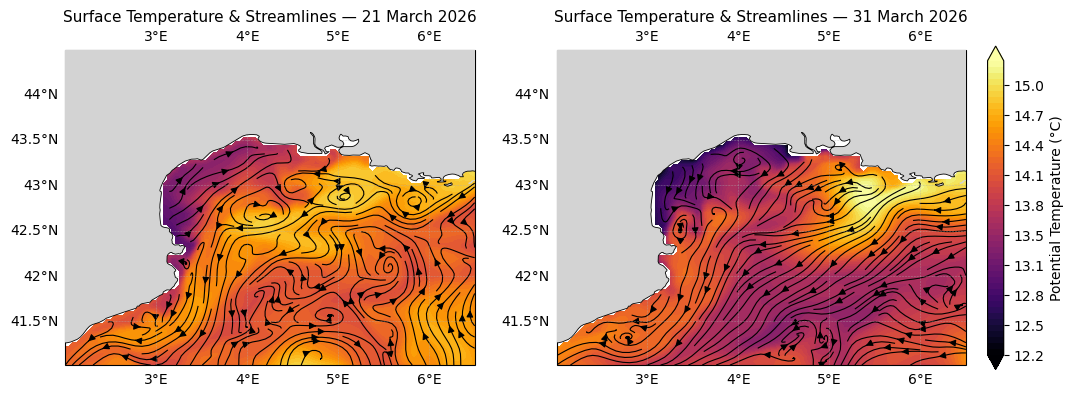

In [13]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import copernicusmarine

DATES = ['2026-03-21', '2026-03-31']
TITLES = ['21 March 2026', '31 March 2026']

slices = [da_march.sel(time=d, depth=depths_actual[0]) for d in DATES]

vmin = float(min(s.min() for s in slices))
vmax = float(max(s.max() for s in slices))
levels = np.linspace(vmin, vmax, 50)

lon = slices[0].longitude.values
lat = slices[0].latitude.values

# --- Carica correnti per le streamlines ---
ds_cur = copernicusmarine.open_dataset(dataset_id='cmems_mod_med_phy-cur_my_4.2km_P1D-m')
cur_data = []
for date in DATES:
    u = ds_cur['uo'].sel(depth=0, time=date, method='nearest').sel(longitude=slice(2.0, 6.5), latitude=slice(41.0, 44.5)).load()
    v = ds_cur['vo'].sel(depth=0, time=date, method='nearest').sel(longitude=slice(2.0, 6.5), latitude=slice(41.0, 44.5)).load()
    cur_data.append({'u': u.values, 'v': v.values})

fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 6),
    subplot_kw={'projection': ccrs.PlateCarree()},
)

for ax, da_t, cur, title in zip(axes, slices, cur_data, TITLES):
    cf = ax.contourf(
        lon, lat, da_t.values,
        levels=levels,
        cmap='inferno',
        transform=ccrs.PlateCarree(),
        extend='both',
    )
    ax.streamplot(
        lon, lat, cur['u'], cur['v'],
        transform=ccrs.PlateCarree(),
        density=2,
        linewidth=0.8,
        color='black',
        arrowsize=1.0,
    )
    ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=3)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6, zorder=4)
    gl = ax.gridlines(draw_labels=True, linewidth=0.4, linestyle='--', alpha=0.6)
    gl.right_labels = False
    ax.set_extent([lon.min(), lon.max(), lat.min(), lat.max()], crs=ccrs.PlateCarree())
    ax.set_title(f'Surface Temperature & Streamlines — {title}', fontsize=11)

cbar = fig.colorbar(cf, ax=axes, label='Potential Temperature (°C)', shrink=0.7, pad=0.02)
cbar.ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

plt.show()